# Ocean MultiScale MeshGraph

In this notebook different meshes for the data-driven model under development are explored. The first is the icosahedral multi-mesh used by GraphCast as is, the second is a masked version of the previous, finally, a hierarchical triangle mesh obtained with `seamsh` has been considered.

In future revisions it should include also a display of mesh size fields, including those based on statistics (the one using average SST interpolation error estimate or the one using the Courant condition).

In [1]:
from pathlib import Path

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import xarray
from geopy.geocoders import Nominatim

from graphcast import mesh_connectivity
from graphcast import mesh_graph
from graphcast import ocean_mesh_utils
from graphcast import plot_utils

In [2]:
save_figures = True

output_dir = Path('outputs/multiscale_meshgraph')
if not output_dir.exists():
  output_dir.mkdir(parents=True)

In [3]:
# The zoom-ins will be around the following area.
geolocator = Nominatim(user_agent="multiscale_meshgraph")
location = geolocator.geocode("Roma")
width, height = 10.0, 10.0
bounds = [location.longitude - width / 2, location.longitude + width / 2,
          location.latitude - height / 2, location.latitude + height / 2]

In [4]:
dataset = xarray.open_zarr('../data/dataset/dataset_tres-1d_res-0p25_levels-10')
dataset

<xarray.Dataset> Size: 2GB
Dimensions:                              (time: 7, lat: 721, lon: 1440,
                                          level: 10)
Coordinates:
    depth                                (level) float32 40B dask.array<chunksize=(1,), meta=np.ndarray>
  * lat                                  (lat) float32 3kB -90.0 -89.75 ... 90.0
  * level                                (level) int64 80B 0 4 8 12 ... 28 32 34
  * lon                                  (lon) float32 6kB 0.0 0.25 ... 359.8
  * time                                 (time) datetime64[ns] 56B 2000-01-01...
Data variables: (12/33)
    10m_u_component_of_wind              (time, lat, lon) float32 29MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    10m_v_component_of_wind              (time, lat, lon) float32 29MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    2m_dewpoint_temperature              (time, lat, lon) float32 29MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    2m_temperature                       (time, lat, lon) float32 29MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    deptho                               (lat, lon) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    dis24                                (time, lat, lon) float32 29MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    ...                                   ...
    vsdy                                 (time, lat, lon) float32 29MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    vsi                                  (time, lat, lon) float32 29MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    vtm02                                (time, lat, lon) float32 29MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    waverys_deptho                       (lat, lon) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    waverys_mask                         (lat, lon) bool 1MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    zos                                  (time, lat, lon) float32 29MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
Attributes:
    last_updated:           2025-07-17 01:52:23.900829+00:00
    valid_time_start:       1940-01-01
    valid_time_stop:        2025-04-30
    valid_time_stop_era5t:  2025-07-11

## Cartesian Grids

In [5]:
mask = dataset['glorys_mask'].isel(level=0, drop=True)

grid_lon, grid_lat = np.meshgrid(mask['lon'], mask['lat'])
masked_grid_lon = grid_lon[mask.astype(bool)]
masked_grid_lat = grid_lat[mask.astype(bool)]

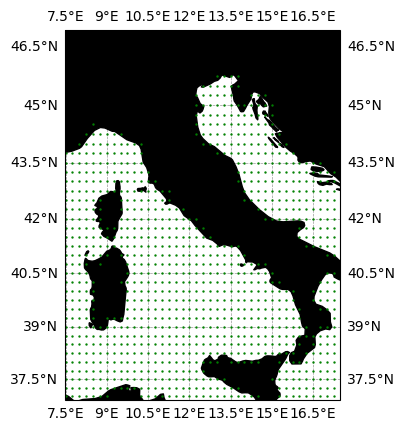

In [6]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Mercator())
ax.set_extent(bounds)
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '50m', edgecolor='face', facecolor='black'))
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.4, color='k', linestyle='--')

ax.scatter(masked_grid_lon, masked_grid_lat, marker='.', color="green", s=2.0, zorder=2, transform=ccrs.PlateCarree())

if save_figures:
  plt.savefig(output_dir / 'grid_res-0.25_zoomin.png', bbox_inches='tight')


## Hierarchical Triangle Mesh

In [7]:
coarse_ocean_mesh = ocean_mesh_utils.read_mesh('../data/geometry/constant_size_coarse.msh')
coarse_ocean_mesh = mesh_connectivity.get_mesh_within_box(coarse_ocean_mesh, bounds)
coarse_ocean_mesh_graph = mesh_graph.mesh_to_wgs(coarse_ocean_mesh)

In [10]:
fine_ocean_mesh = ocean_mesh_utils.read_mesh('../data/geometry/constant_size_fine.msh')
fine_ocean_mesh = mesh_connectivity.get_mesh_within_box(fine_ocean_mesh, bounds)
fine_ocean_mesh_graph = mesh_graph.mesh_to_wgs(fine_ocean_mesh)

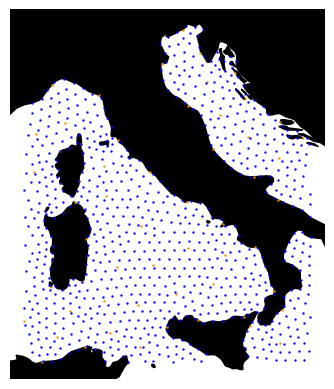

In [11]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Mercator())
ax.axis('off')
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '50m', edgecolor='face', facecolor='black'))

latitudes, longitudes = coarse_ocean_mesh_graph.vertices
ax.scatter(longitudes, latitudes, marker='.', color="darkorange", s=2.0, zorder=2, transform=ccrs.PlateCarree())

latitudes, longitudes = fine_ocean_mesh_graph.vertices
ax.scatter(longitudes, latitudes, marker='.', color="blue", s=2.0, zorder=2, transform=ccrs.PlateCarree())

if save_figures:
  plt.savefig(output_dir / 'latent_representation.png', bbox_inches='tight')

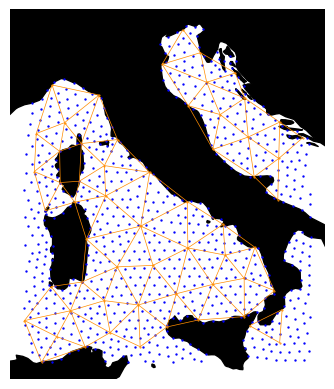

In [12]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Mercator())
ax.axis('off')
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '50m', edgecolor='face', facecolor='black'))

# Add coarse mesh vertices
latitudes, longitudes = coarse_ocean_mesh_graph.vertices
ax.scatter(longitudes, latitudes, marker='.', color="darkorange", s=1.0, zorder=2, transform=ccrs.PlateCarree())

# Add fine mesh vertices
latitudes, longitudes = fine_ocean_mesh_graph.vertices
ax.scatter(longitudes, latitudes, marker='.', color="blue", s=2.0, zorder=2, transform=ccrs.PlateCarree())

# Add coarse mesh edges
lc = plot_utils.get_line_collection(coarse_ocean_mesh_graph, linewidths=0.5, colors="darkorange", transform=ccrs.Geodetic())
ax.add_collection(lc)

if save_figures:
  plt.savefig(output_dir / 'coarse_meshgraph.png', bbox_inches='tight')


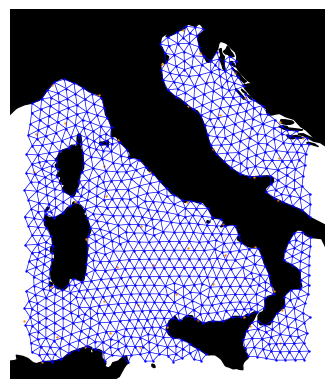

In [13]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Mercator())
ax.axis('off')
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '50m', edgecolor='face', facecolor='black'))

# Add coarse mesh vertices
latitudes, longitudes = coarse_ocean_mesh_graph.vertices
ax.scatter(longitudes, latitudes, marker='.', color="darkorange", s=2.0, zorder=2, transform=ccrs.PlateCarree())

# Add fine mesh vertices
latitudes, longitudes = fine_ocean_mesh_graph.vertices
ax.scatter(longitudes, latitudes, marker='.', color="blue", s=2.0, zorder=2, transform=ccrs.PlateCarree())

# Add fine mesh edges
lc = plot_utils.get_line_collection(fine_ocean_mesh_graph, linewidths=0.5, colors="blue", transform=ccrs.Geodetic())
ax.add_collection(lc)

if save_figures:
    plt.savefig(output_dir / 'fine_meshgraph.png', bbox_inches='tight')

In [14]:
dummy_multiscale_typed_graph = mesh_connectivity.get_dummy_xscaling_graph(coarse_ocean_mesh, fine_ocean_mesh)

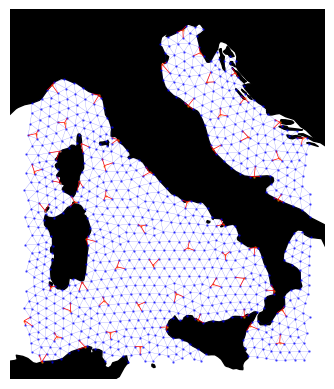

In [15]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Mercator())
ax.axis('off')
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '50m', edgecolor='face', facecolor='black'))

# Add fine mesh vertices
latitudes, longitudes = fine_ocean_mesh_graph.vertices
ax.scatter(longitudes, latitudes, marker='.', color="blue", alpha=0.6, s=2.0, zorder=2, transform=ccrs.PlateCarree())

# Add fine mesh edges with alpha
lc = plot_utils.get_line_collection(fine_ocean_mesh_graph, linewidths=0.16, colors="blue", alpha=0.6, transform=ccrs.Geodetic())
ax.add_collection(lc)

# Add coarse mesh vertices
latitudes, longitudes = coarse_ocean_mesh_graph.vertices
ax.scatter(longitudes, latitudes, marker='.', color="darkorange", alpha=0.6, s=2.0, zorder=2, transform=ccrs.PlateCarree())

# Add downsampling ("fine2coarse") edges
downsampling_wgs_graph = mesh_graph.typed_to_wgs(dummy_multiscale_typed_graph, edge_set_name="fine2coarse")
lc = plot_utils.get_line_collection(downsampling_wgs_graph, linewidths=0.5, colors="red", transform=ccrs.Geodetic())
ax.add_collection(lc)

if save_figures:
  plt.savefig(output_dir / 'downsample.png', bbox_inches='tight')


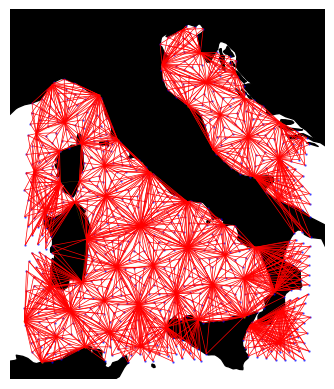

In [16]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Mercator())
ax.axis('off')
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '50m', edgecolor='face', facecolor='black'))

# Add coarse mesh vertices
lc = plot_utils.get_line_collection(coarse_ocean_mesh_graph, linewidths=0.16, colors="darkorange", alpha=0.6, transform=ccrs.Geodetic())
ax.add_collection(lc)

# Add coarse mesh edges with alpha
latitudes, longitudes = coarse_ocean_mesh_graph.vertices
ax.scatter(longitudes, latitudes, marker='.', color="darkorange", alpha=0.6, s=2.0, zorder=2, transform=ccrs.PlateCarree())

# Plot fine mesh vertices
latitudes, longitudes = fine_ocean_mesh_graph.vertices
ax.scatter(longitudes, latitudes, marker='.', color="blue", alpha=0.6, s=2.0, zorder=2, transform=ccrs.PlateCarree())

# Add downsampling ("fine2coarse") edges
downsampling_wgs_graph = mesh_graph.typed_to_wgs(dummy_multiscale_typed_graph, edge_set_name="coarse2fine")
lc = plot_utils.get_line_collection(downsampling_wgs_graph, linewidths=0.5, colors="red", transform=ccrs.Geodetic())
ax.add_collection(lc)

if save_figures:
  plt.savefig(output_dir / 'upsample.png', bbox_inches='tight')
